In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Churn_Modelling.xls")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [7]:
df.head()       #gives only first five rows 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.tail()       #gives only last five rows 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [87]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [13]:
df[df['Balance']>80000]      #gives the values whose balance is above 80000

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9986,9987,15581736,Bartlett,673,Germany,Male,47,1,183579.54,2,0,1,34047.54,0
9987,9988,15588839,Mancini,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,0
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0


In [40]:
Surname_Geography_Gender=df[['Surname','Geography','Gender']]
Surname_Geography_Gender.head()

,Surname,Geography,Gender
0,Hargrave,France,Female
1,Hill,Spain,Female
2,Onio,France,Female
3,Boni,France,Female
4,Mitchell,Spain,Female


In [39]:
df.iloc[1:11,1:9]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance
1,15647311,Hill,608,Spain,Female,41,1,83807.86
2,15619304,Onio,502,France,Female,42,8,159660.80
3,15701354,Boni,699,France,Female,39,1,0.00
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82
5,15574012,Chu,645,Spain,Male,44,8,113755.78
6,15592531,Bartlett,822,France,Male,50,7,0.00
7,15656148,Obinna,376,Germany,Female,29,4,115046.74
8,15792365,He,501,France,Male,44,4,142051.07
9,15592389,H?,684,France,Male,27,2,134603.88
10,15767821,Bearce,528,France,Male,31,6,102016.72


In [88]:
df.groupby(['Geography'])[['Gender']].count()

,Gender
Geography,
France,5014
Germany,2509
Spain,2477


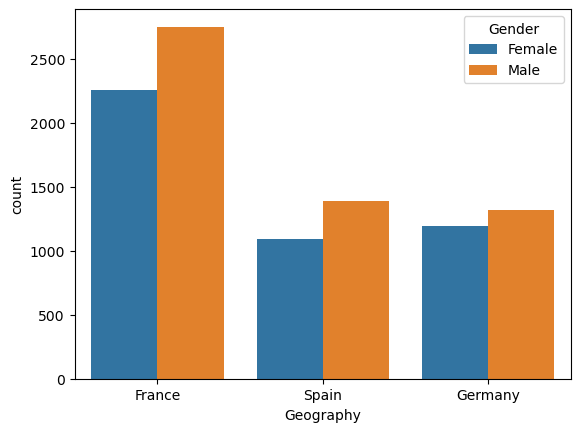

In [46]:
sns.countplot(x='Geography',hue='Gender',data=df)
plt.show()

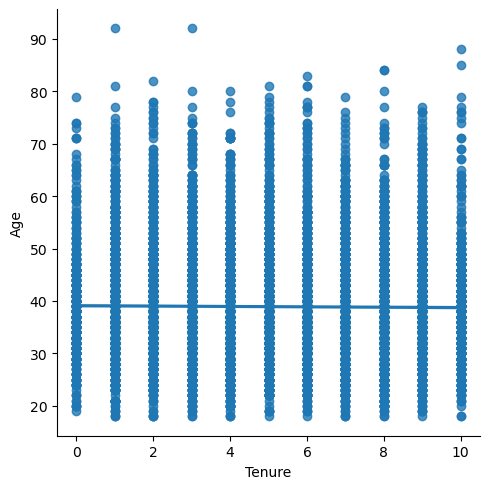

In [50]:
sns.lmplot(x='Tenure',y='Age', data= df)
plt.show()

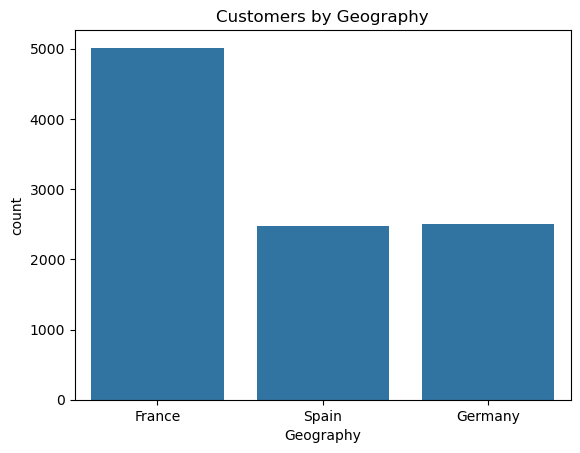

In [54]:

sns.countplot(x='Geography',data=df
             )
plt.title('Customers by Geography')
plt.show()

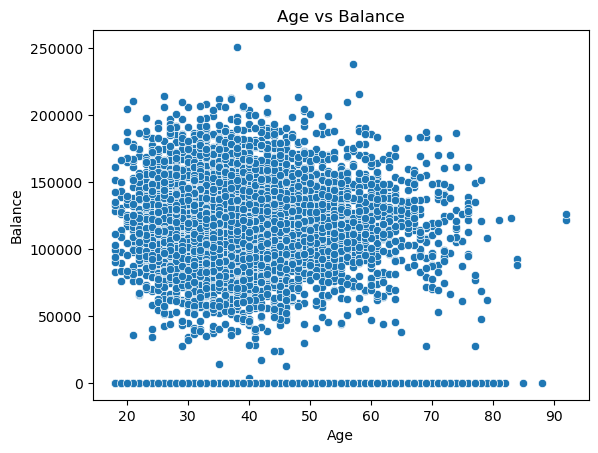

In [57]:
sns.scatterplot(data=df, x='Age', y='Balance')
plt.title('Age vs Balance')
plt.show()

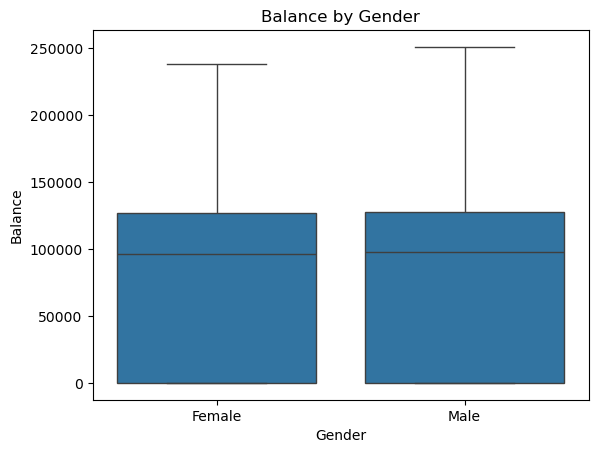

In [59]:
sns.boxplot(data=df, x='Gender', y='Balance')
plt.title('Balance by Gender')
plt.show()

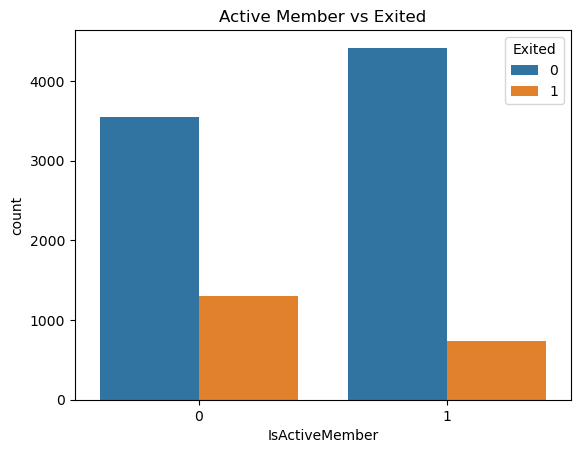

In [60]:
sns.countplot(data=df, x='IsActiveMember', hue='Exited')
plt.title('Active Member vs Exited')
plt.show()

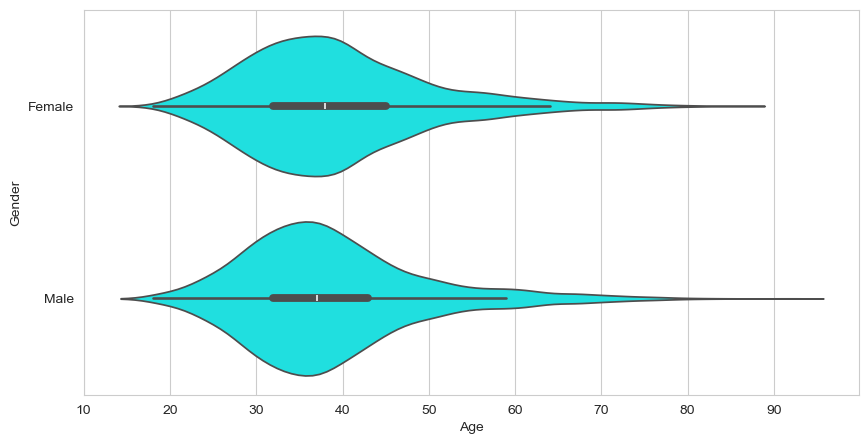

In [66]:
sns.set_style('whitegrid')
plt.figure(figsize = (10,5))
sns.violinplot(x="Age",y="Gender",data=df,color='cyan')
plt.show()

In [93]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis = 1,inplace=True)

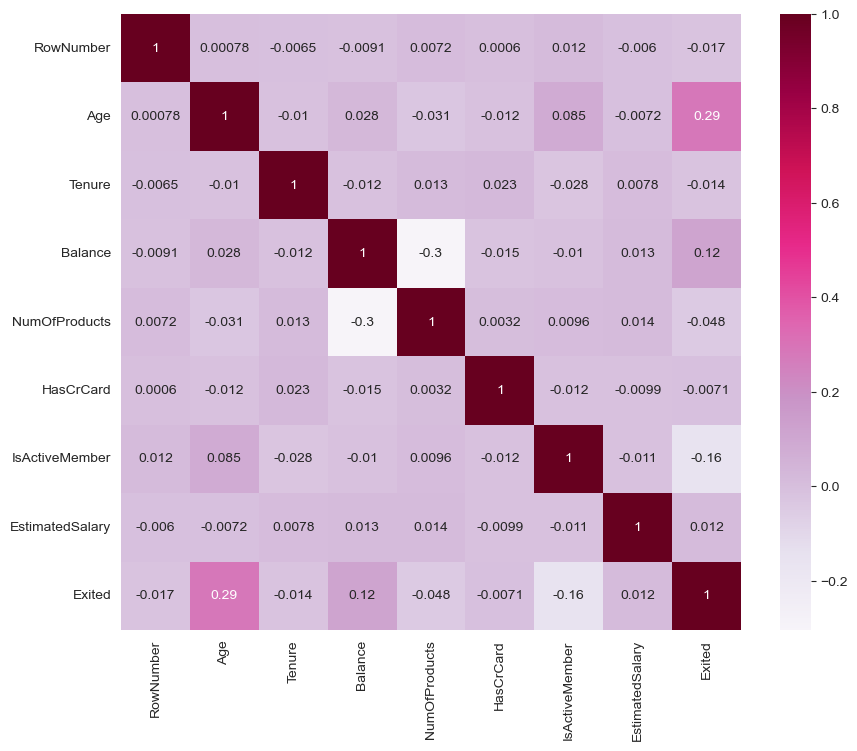

In [108]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="PuRd", annot=True)
plt.show()

In [112]:
sns.kdeplot(df.Age[df['Exited'] == 0], color='Red', fill=True, label='No Churn')
sns.kdeplot(df.Age[df['Exited'] == 1], color='Blue', fill=True, label='Churn')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution by Churn (KDE)')
plt.show()

AttributeError: 'NoneType' object has no attribute 'Age'